# Exploratory Data Analysis (EDA)

## Project
**E-Commerce Return Rate Reduction Analysis**

### Objective

This notebook performs exploratory data analysis on the cleaned e-commerce dataset to identify patterns, trends, and relationships associated with product returns.

The insights generated during this phase will:

- Validate findings from the SQL business analysis.
- Identify factors influencing product returns.
- Support feature selection for predictive modeling.
- Provide business insights for dashboard development.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv(r"C:\Users\krish\ecommerce_returns_clean.csv")

df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivered_date,region,returned,request_date,return_reason,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,delivery_days,age_group
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,2023-12-27,West,0,NaN,NaN,139.47,7.88,31.17,60,Female,4,46-60
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,2025-04-09,South,0,NaN,NaN,24.73,4.60,-2.62,37,Male,6,36-45
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,2024-10-12,North,0,NaN,NaN,166.80,6.58,13.44,34,Male,4,26-35
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,2024-09-20,South,0,NaN,NaN,63.67,5.50,2.14,21,Female,6,18-25
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,2024-12-27,East,0,NaN,NaN,13.88,2.74,1.15,39,Male,6,36-45


In [4]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 34500
Columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         34500 non-null  str    
 1   customer_id      34500 non-null  str    
 2   product_id       34500 non-null  str    
 3   category         34500 non-null  str    
 4   price            34500 non-null  float64
 5   discount         34500 non-null  float64
 6   quantity         34500 non-null  int64  
 7   payment_method   34500 non-null  str    
 8   order_date       34500 non-null  str    
 9   delivered_date   34500 non-null  str    
 10  region           34500 non-null  str    
 11  returned         34500 non-null  int64  
 12  request_date     1903 non-null   str    
 13  return_reason    1903 non-null   str    
 14  total_amount     34500 non-null  float64
 15  shipping_cost    34500 non-null  float64
 16  profit_margin    34500 non-null  float64
 17 

## 1. Return Distribution

Understanding the distribution of returned and non-returned orders provides an overview of the target variable and helps identify any class imbalance within the dataset.

This analysis is particularly important because predictive models can become biased when one class significantly outweighs the other.

In [5]:
# Calculate return distribution

return_counts = df["returned"].value_counts().sort_index()

return_percentage = (
    df["returned"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

summary = pd.DataFrame({
    "Count": return_counts,
    "Percentage": return_percentage.round(2)
})

summary.index = ["Not Returned", "Returned"]

summary

,Count,Percentage
Not Returned,32597,94.48
Returned,1903,5.52


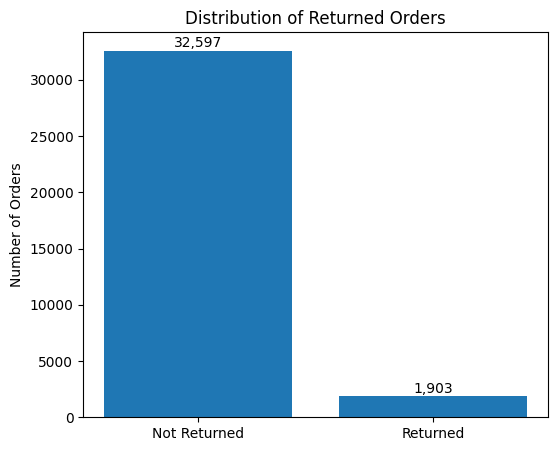

In [6]:
plt.figure(figsize=(6,5))

bars = plt.bar(
    ["Not Returned", "Returned"],
    return_counts.values
)

plt.title("Distribution of Returned Orders")
plt.ylabel("Number of Orders")

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 300,
        f"{int(height):,}",
        ha="center",
        fontsize=10
    )
plt.savefig(
    "downloads/outputs/figures/return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Interpretation

- The dataset contains **32,597 non-returned orders** and **1,903 returned orders**.
- Only **5.52%** of all orders were returned, indicating that returns are relatively uncommon.
- This imbalance should be considered during predictive modeling, as models trained on imbalanced datasets may become biased toward the majority class.

**Business Insight**

Although the return rate is low, the SQL analysis showed that returned orders account for over **388,000** in returned sales value, highlighting the importance of accurately identifying high-risk orders.

## 2. Order Distribution by Product Category

Before comparing return rates, it is important to understand how customer orders are distributed across product categories.

This analysis identifies which categories contribute the largest share of total orders and provides context for interpreting return performance.

In [7]:
# Order distribution by category

category_orders = (
    df["category"]
    .value_counts()
    .sort_values(ascending=False)
)

category_orders

category
Fashion        6254
Electronics    6180
Home           5487
Toys           4247
Sports         4171
Beauty         4103
Grocery        4058
Name: count, dtype: int64

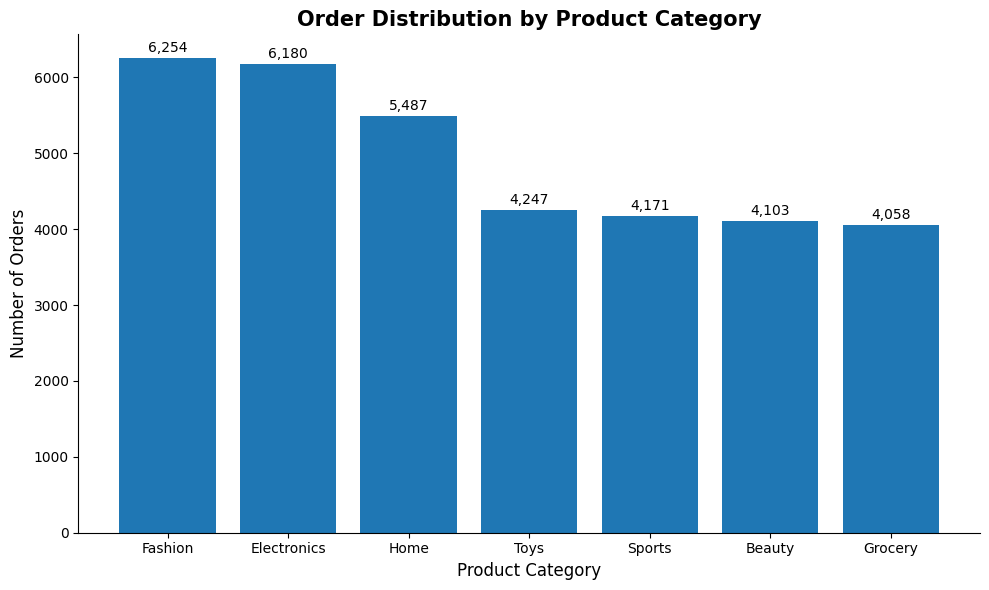

In [8]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    category_orders.index,
    category_orders.values
)

plt.title("Order Distribution by Product Category", fontsize=15, weight="bold")
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

# Remove unnecessary borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 80,
        f"{height:,}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/order_distribution_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Fashion and Electronics account for the largest share of customer orders.
- Grocery records the fewest orders among all product categories.
- The distribution of orders varies noticeably across categories, providing important context for subsequent return rate analysis.

### Business Insight

A high number of returned orders does not necessarily indicate poor performance. Categories with greater sales volume naturally experience more returns. Evaluating return rates alongside order volume provides a more accurate assessment of category performance.

## 3. Return Reason Analysis

Understanding why customers return products is essential for developing effective return reduction strategies.

This analysis examines the frequency of each return reason to identify the primary drivers of product returns and highlight areas where the business can take corrective action.

In [9]:
# Return reason distribution

return_reason_summary = (
    df[df["returned"] == 1]["return_reason"]
    .value_counts()
)

return_reason_summary

return_reason
Not as described      490
No longer needed      481
Defective             465
Missing/Wrong item    439
Slow delivery          28
Name: count, dtype: int64

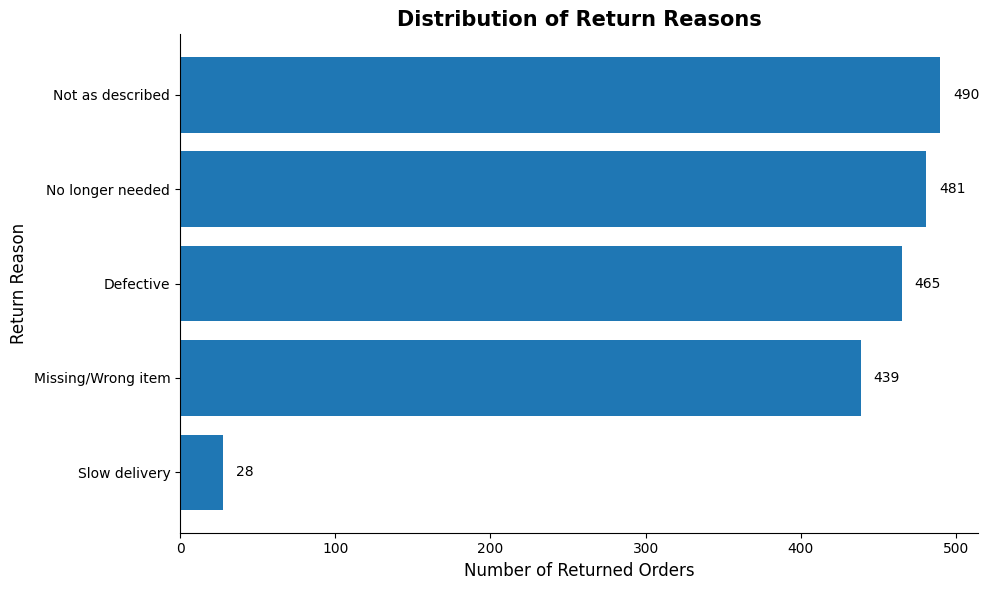

In [10]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    return_reason_summary.index,
    return_reason_summary.values
)

plt.title("Distribution of Return Reasons", fontsize=15, weight="bold")
plt.xlabel("Number of Returned Orders", fontsize=12)
plt.ylabel("Return Reason", fontsize=12)

# Remove unnecessary borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 8,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=10
    )

# Highest value at the top
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/return_reason_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- **Not as described** is the most common return reason, accounting for **490 returned orders**.
- **No longer needed**, **Defective**, and **Missing/Wrong item** also contribute substantially to total returns.
- **Slow delivery** is the least common reason, representing only a small fraction of returned orders.

### Business Insight

The majority of returns are driven by **product-related issues** rather than delivery performance. This indicates that improvements in product quality, product descriptions, and order fulfillment accuracy could significantly reduce return rates.

### Recommendation

The business should prioritize:

- Improving product descriptions and specifications.
- Strengthening product quality assurance.
- Reducing warehouse picking and packing errors.

These initiatives are expected to have a greater impact on reducing returns than focusing solely on delivery performance.

## 4. Region Distribution

This analysis examines how customer orders are distributed across different geographical regions.

Understanding the regional distribution of orders provides context for subsequent analyses of regional return performance.

In [11]:
# Order distribution by region

region_distribution = (
    df["region"]
    .value_counts()
    .sort_values(ascending=False)
)

region_distribution

region
South      7584
North      7572
East       6904
West       6808
Central    5632
Name: count, dtype: int64

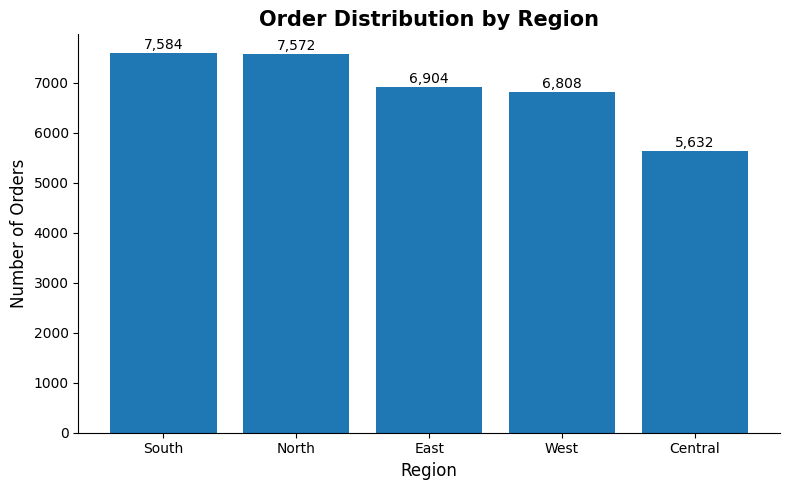

In [12]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    region_distribution.index,
    region_distribution.values
)

plt.title("Order Distribution by Region", fontsize=15, weight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 80,
        f"{height:,}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/order_distribution_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Customer orders are relatively evenly distributed across the five regions.
- South and North account for the highest number of orders, while Central records the fewest.
- No region overwhelmingly dominates the dataset.

### Business Insight

The balanced regional distribution improves the reliability of regional comparisons performed later in the analysis and reduces the risk of conclusions being driven by highly unequal sample sizes.

## 2.5 Payment Method Distribution

This analysis examines the distribution of customer payment methods used across all orders.

Understanding payment preferences provides useful business insights and helps determine whether payment method should be considered as a potential predictor in the return prediction model.

In [13]:
# Payment method distribution

payment_distribution = (
    df["payment_method"]
    .value_counts()
    .sort_values(ascending=False)
)

payment_distribution

payment_method
Credit Card    12170
Debit Card      8505
COD             4160
UPI             4156
PayPal          3444
Wallet          2065
Name: count, dtype: int64

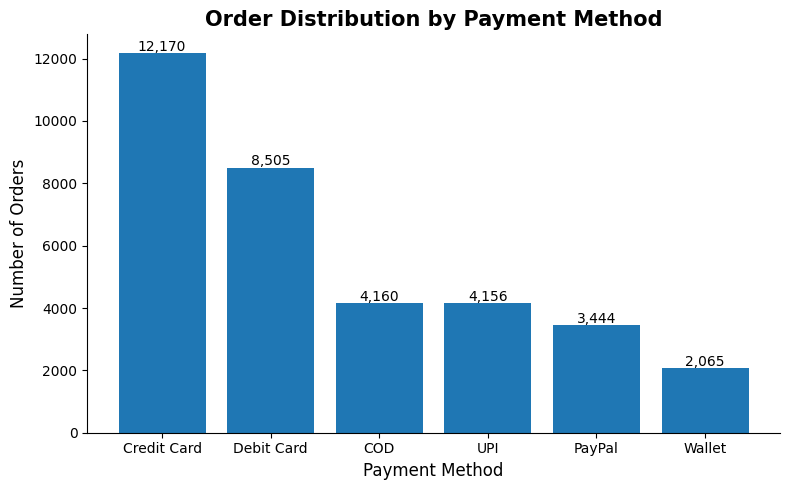

In [14]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    payment_distribution.index,
    payment_distribution.values
)

plt.title("Order Distribution by Payment Method", fontsize=15, weight="bold")
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 80,
        f"{height:,}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/payment_method_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- **Credit Card** is the most frequently used payment method, accounting for **12,170 orders (35.3%)**.
- **Debit Card** is the second most common payment method with **8,505 orders (24.7%)**.
- **COD** and **UPI** have similar usage, each contributing approximately **12%** of total orders.
- **Wallet** is the least frequently used payment method, representing a small proportion of customer transactions.

### Business Insight

The distribution indicates that electronic payment methods dominate customer purchases, with credit and debit cards accounting for nearly **60%** of all orders. Since payment method is available at the time of purchase, it may serve as a useful predictor in the return prediction model if certain payment methods exhibit higher return rates than others.

### Recommendation

In the subsequent bivariate analysis, we will investigate whether return rates differ across payment methods to determine if payment behavior is associated with product returns.

## 2.6 Customer Age Distribution

Customer age is an important demographic variable that may influence purchasing and return behavior.

This analysis examines the distribution of customer ages to understand the composition of the customer base and identify any noticeable patterns or outliers.

In [15]:
# Summary statistics for customer age

df["customer_age"].describe()

count    34500.000000
mean        43.474377
std         14.980682
min         18.000000
25%         31.000000
50%         43.000000
75%         56.000000
max         69.000000
Name: customer_age, dtype: float64

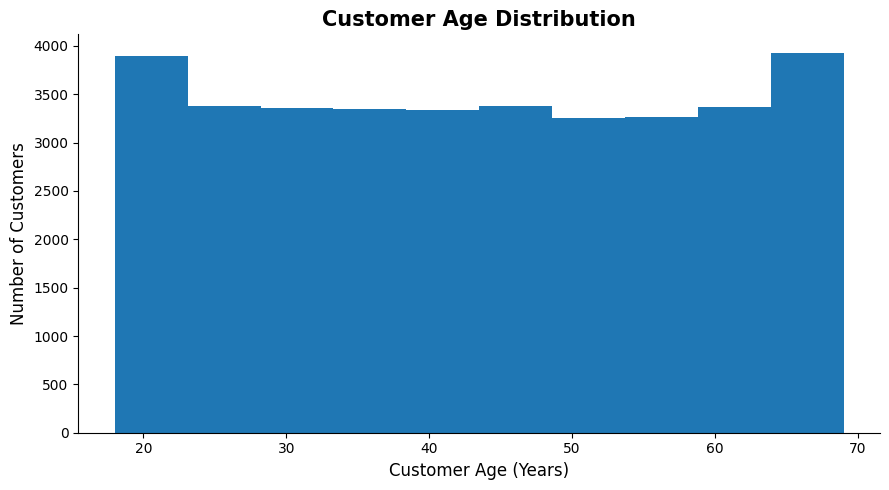

In [16]:
plt.figure(figsize=(9,5))

plt.hist(
    df["customer_age"],
    bins=10,
)

plt.title("Customer Age Distribution", fontsize=15, weight="bold")
plt.xlabel("Customer Age (Years)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/customer_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Customer ages range from **18 to 69 years**, with an average age of approximately **43 years**.
- The distribution is relatively balanced across the adult age groups, with no extreme concentration in a single age range.
- No obvious outliers or unusual age values are observed, indicating good data quality.

### Business Insight

The dataset represents a broad customer demographic, making it suitable for evaluating whether age influences product return behavior. Since the customer base spans multiple age groups, age is a valuable feature to include in the predictive model.

### Recommendation

In the bivariate analysis, customer age groups will be compared against return rates to determine whether certain age segments are more likely to return products.

## 2.7 Customer Gender Distribution

This analysis examines the distribution of customers by gender to understand the demographic composition of the customer base.

Understanding gender representation provides context for later analyses that investigate whether return behavior differs across customer demographics.

In [17]:
# Customer gender distribution

gender_distribution = (
    df["customer_gender"]
    .value_counts()
)

gender_distribution

customer_gender
Female    16818
Male      16310
Other      1372
Name: count, dtype: int64

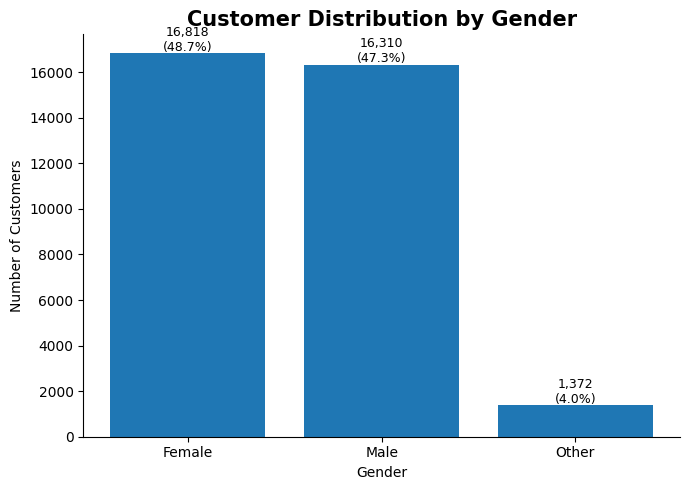

In [19]:
# Calculate percentages

gender_percentage = (
    gender_distribution /
    gender_distribution.sum() * 100
)

plt.figure(figsize=(7,5))

bars = plt.bar(
    gender_distribution.index,
    gender_distribution.values
)

plt.title("Customer Distribution by Gender", fontsize=15, weight="bold")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = gender_percentage.iloc[i]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 120,
        f"{height:,}\n({pct:.1f}%)",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/customer_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Female customers account for **16,818 orders (48.7%)**, representing the largest customer segment.
- Male customers contribute **16,310 orders (47.3%)**, resulting in a nearly balanced distribution.
- The **Other** category accounts for **1,372 orders (4.0%)**.

### Business Insight

The customer base is well balanced between male and female customers, reducing the likelihood that later analyses are biased toward a single demographic group.

### Recommendation

In the bivariate analysis, return rates will be compared across gender groups to determine whether customer gender has any meaningful influence on return behavior.

## 2.8 Product Price Distribution

This analysis examines the distribution of product prices to understand the pricing structure of products sold on the platform.

Understanding the spread of product prices helps identify whether the dataset is dominated by low-priced or high-priced products and provides context for subsequent analyses involving product returns.

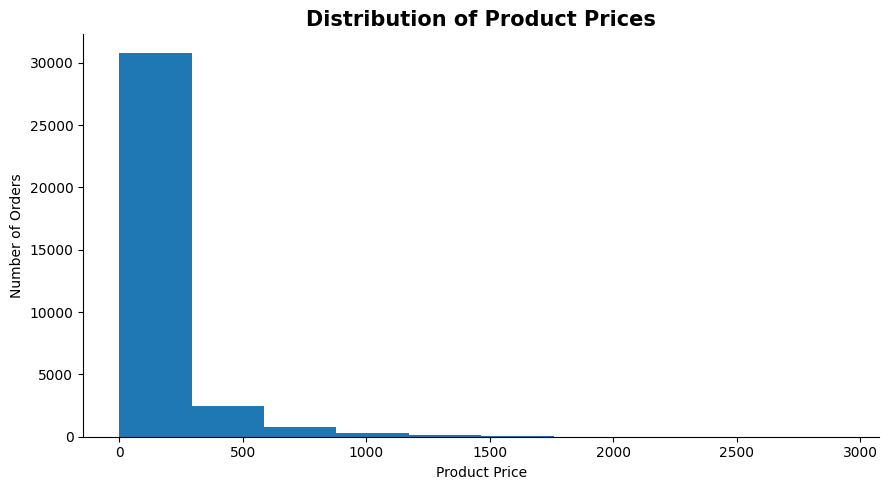

In [22]:
plt.figure(figsize=(9,5))

plt.hist(
    df["price"],
    bins=10
)

plt.title("Distribution of Product Prices", fontsize=15, weight="bold")
plt.xlabel("Product Price")
plt.ylabel("Number of Orders")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/product_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

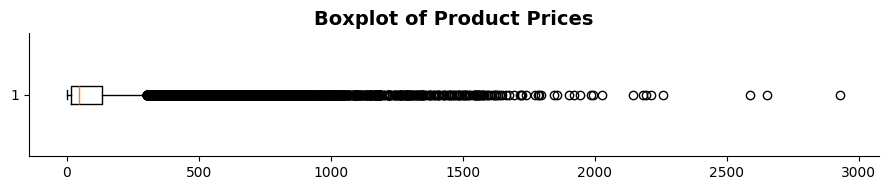

In [24]:
plt.figure(figsize=(9,2))

plt.boxplot(
    df["price"],
    vert=False
)

plt.title("Boxplot of Product Prices", fontsize=14, weight="bold")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/product_price_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Product prices range from **₹1.01** to **₹2,930.47**, with a median price of **₹45.66** and an average price of **₹119.39**.
- The distribution is **highly right-skewed** (skewness = **3.70**), indicating that most products are low to moderately priced, while a relatively small number of premium-priced products create a long right tail.
- The large difference between the mean and median further confirms the presence of high-priced outliers.

### Business Insight

The product catalog is primarily composed of affordable items, with a limited number of premium products. Since purchasing behavior may vary by price point, product price is an important feature to evaluate when predicting product returns.

## 2.8 Total Order Value Distribution

This analysis examines the distribution of total order values across all customer purchases.

Understanding how much customers typically spend per order provides valuable insight into purchasing behavior and helps identify the presence of high-value transactions that may have a significant financial impact if returned.

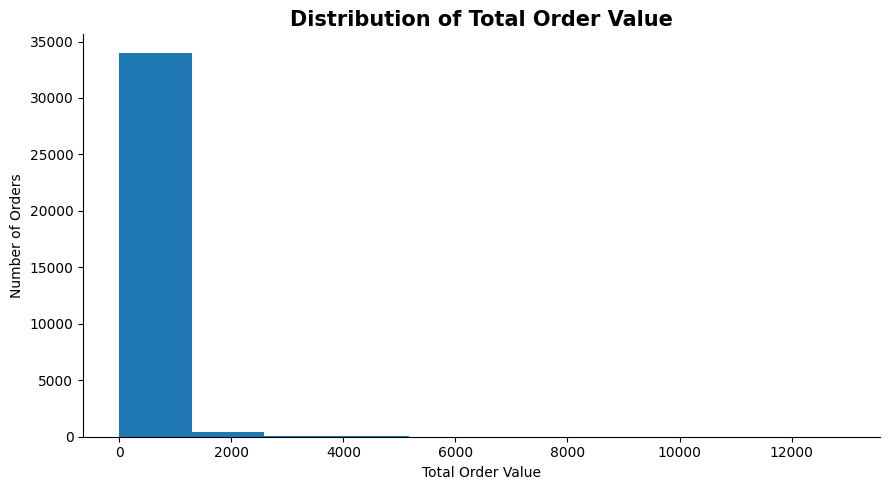

In [29]:
plt.figure(figsize=(9,5))

plt.hist(
    df["total_amount"],
    bins=10
)

plt.title("Distribution of Total Order Value", fontsize=15, weight="bold")
plt.xlabel("Total Order Value")
plt.ylabel("Number of Orders")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/total_order_value_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

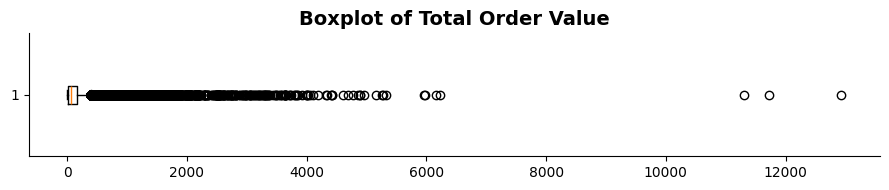

In [30]:
plt.figure(figsize=(9,2))

plt.boxplot(
    df["total_amount"],
    vert=False
)

plt.title("Boxplot of Total Order Value", fontsize=14, weight="bold")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/total_order_value_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Total order values range from **₹0.82** to **₹12,931.80**, with a median order value of **₹56.82** and an average of **₹170.01**.
- The distribution is **highly right-skewed** (skewness = **8.22**), indicating that most customers place relatively low-value orders, while a small number of very high-value purchases create a long right tail.
- The substantial difference between the mean and median confirms the presence of several high-value transactions.

### Business Insight

Although most customer purchases are of relatively low value, a small proportion of high-value orders contributes significantly to overall sales. These transactions represent greater financial risk if returned.

### Recommendation

In the bivariate analysis, we will investigate whether higher-value orders are associated with a greater likelihood of product returns.

## 2.9 Profit Margin Distribution

This analysis examines the distribution of profit margins across all customer orders.

Understanding the distribution of profit margins helps identify how profitable individual orders are and whether a small number of orders contribute disproportionately to overall profitability. This analysis also provides context for evaluating the financial impact of product returns.

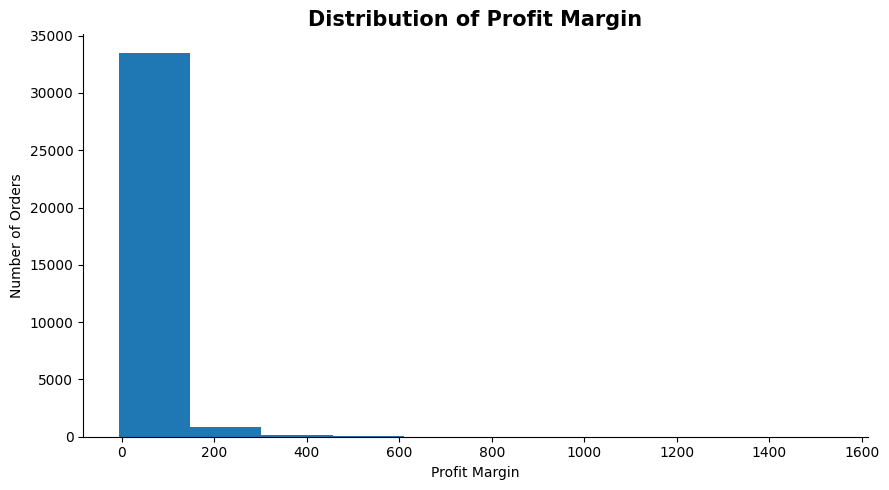

In [32]:
plt.figure(figsize=(9,5))

plt.hist(
    df["profit_margin"],
    bins=10
)

plt.title("Distribution of Profit Margin", fontsize=15, weight="bold")
plt.xlabel("Profit Margin")
plt.ylabel("Number of Orders")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/profit_margin_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

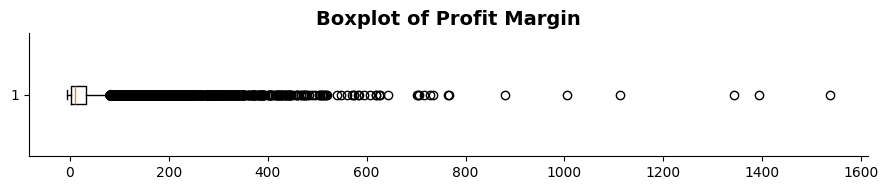

In [33]:
plt.figure(figsize=(9,2))

plt.boxplot(
    df["profit_margin"],
    vert=False
)

plt.title("Boxplot of Profit Margin", fontsize=14, weight="bold")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/profit_margin_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Profit margins range from **-₹6.20** to **₹1,536.17**, with a median profit margin of **₹10.55** and an average of **₹28.12**.
- The distribution is **highly right-skewed** (skewness = **6.04**), indicating that most orders generate relatively low profit margins, while a small number of orders contribute exceptionally high profits.
- The large gap between the mean and median, along with the presence of upper-end outliers, confirms that a few highly profitable orders significantly influence the overall distribution.
- A small number of orders have **negative profit margins**, indicating that these transactions resulted in a financial loss.

### Business Insight

The business earns modest profits from most orders, while a limited number of high-margin orders contribute disproportionately to overall profitability. Returns involving these high-margin products could have a greater financial impact than returns of low-margin products.

### Recommendation

Further analysis should compare profit margins between returned and non-returned orders to determine whether highly profitable products are more or less likely to be returned.

## 2.10 Shipping Cost Distribution

This analysis examines the distribution of shipping costs across all customer orders.

Understanding shipping cost distribution helps assess the consistency of logistics expenses and identify whether shipping charges vary significantly across orders.

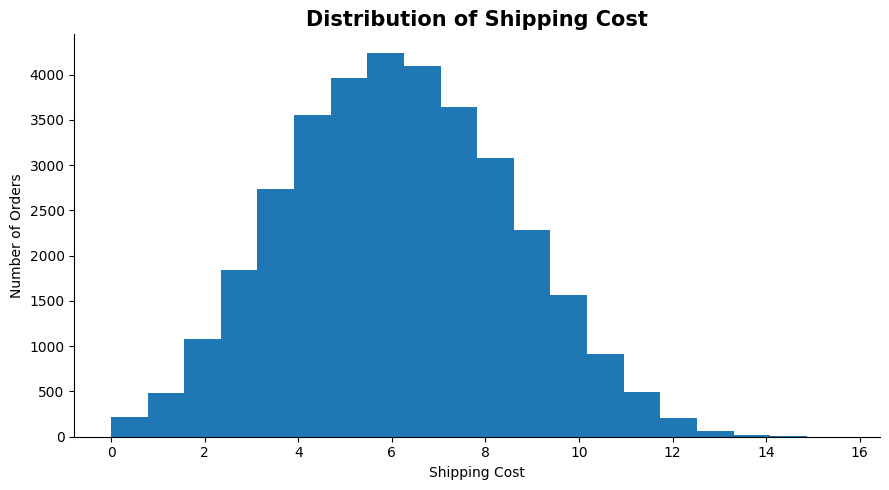

In [34]:
plt.figure(figsize=(9,5))

plt.hist(
    df["shipping_cost"],
    bins=20
)

plt.title("Distribution of Shipping Cost", fontsize=15, weight="bold")
plt.xlabel("Shipping Cost")
plt.ylabel("Number of Orders")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/shipping_cost_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

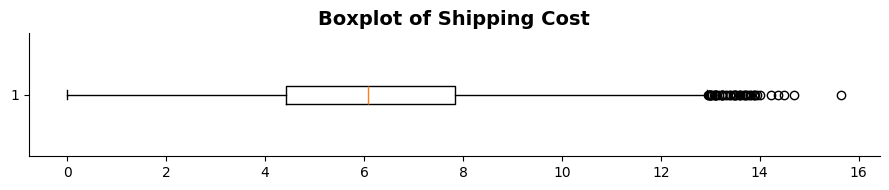

In [36]:
plt.figure(figsize=(9,2))

plt.boxplot(
    df["shipping_cost"],
    vert=False
)

plt.title("Boxplot of Shipping Cost", fontsize=14, weight="bold")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/shipping_cost_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Shipping costs range from **₹0.00** to **₹15.65**, with an average shipping cost of **₹6.15** and a median of **₹6.09**.
- The distribution is **approximately symmetric** (skewness = **0.12**), as indicated by the close agreement between the mean and median.
- Most shipping costs fall within a relatively narrow range (₹4.42–₹7.83), suggesting limited variability across customer orders.
- No evidence of extreme shipping cost values is observed, indicating a fairly standardized shipping pricing structure.

### Business Insight

The consistency in shipping costs suggests that logistics charges are relatively uniform across orders. This indicates that shipping cost is unlikely to be a major factor driving differences in customer purchasing behavior or return decisions.

### Recommendation

In the bivariate analysis, shipping costs can be compared between returned and non-returned orders to verify whether any meaningful relationship exists with product returns, although significant differences are not expected based on the current distribution.

## 2.11 Delivery Days Distribution

This analysis examines the distribution of delivery times across all customer orders.

Delivery time is an important operational metric that influences customer satisfaction and may contribute to product return behavior. Understanding its distribution provides context for evaluating its relationship with returns in later analyses.

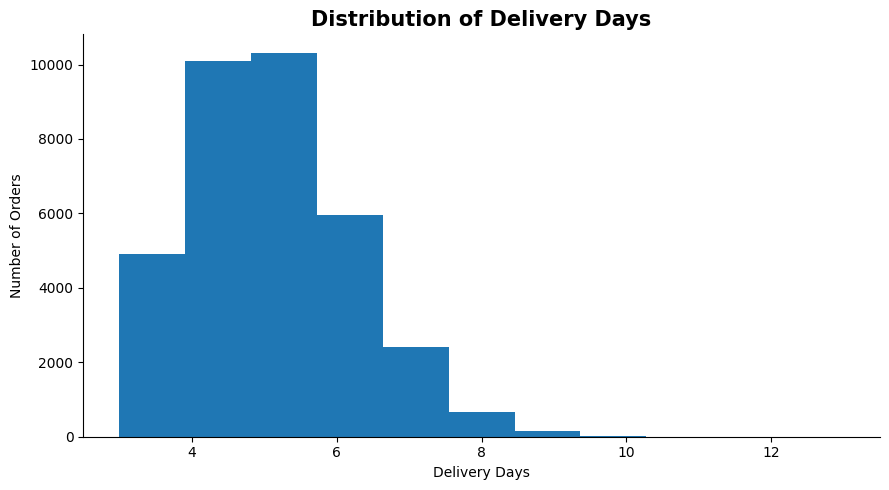

In [38]:
plt.figure(figsize=(9,5))

plt.hist(
    df["delivery_days"],
    bins=11
)

plt.title("Distribution of Delivery Days", fontsize=15, weight="bold")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/delivery_days_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

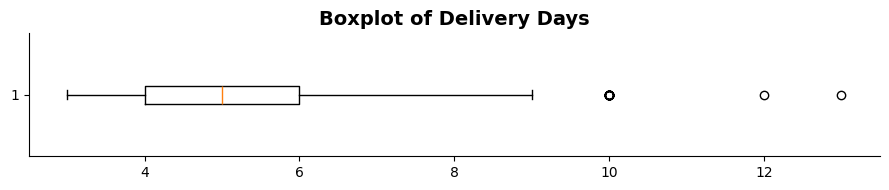

In [39]:
plt.figure(figsize=(9,2))

plt.boxplot(
    df["delivery_days"],
    vert=False
)

plt.title("Boxplot of Delivery Days", fontsize=14, weight="bold")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/delivery_days_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Delivery times range from **3 to 13 days**, with an average delivery time of **4.81 days** and a median of **5 days**.
- The distribution is **slightly right-skewed** (skewness = **0.56**), indicating that while most orders are delivered within a relatively short period, a small number of orders experience longer delivery times.
- The majority of deliveries occur between **4 and 6 days**, as reflected by the interquartile range (Q1 = **4 days**, Q3 = **6 days**), suggesting consistent delivery performance.
- A few orders required significantly longer delivery times, which appear as upper-end outliers in the distribution.

### Business Insight

The business demonstrates generally consistent delivery performance, with most orders reaching customers within one week. While occasional delays occur, they affect only a small proportion of orders.

### Recommendation

In the bivariate analysis, delivery times will be compared between returned and non-returned orders to determine whether longer delivery durations are associated with a higher likelihood of product returns.

# 3. Bivariate Analysis

Bivariate analysis explores the relationship between individual features and the target variable (`returned`).

The objective is to identify the factors associated with higher return rates and uncover actionable business insights that can help reduce product returns.

## 3.1 Return Rate by Product Category

This analysis compares return rates across product categories to identify which product segments contribute most to overall returns.

Understanding category-level return behavior helps businesses prioritize quality improvements, product description enhancements, and return reduction strategies.

In [40]:
category_returns = (
    df.groupby("category")
      .agg(
          total_orders=("returned", "count"),
          returned_orders=("returned", "sum")
      )
)

category_returns["return_rate"] = (
    category_returns["returned_orders"] /
    category_returns["total_orders"] * 100
)

category_returns = category_returns.sort_values(
    "return_rate",
    ascending=False
)

category_returns

,total_orders,returned_orders,return_rate
category,,,
Fashion,6254,518,8.282699
Electronics,6180,451,7.297735
Home,5487,310,5.649718
Toys,4247,210,4.944667
Sports,4171,206,4.938864
Beauty,4103,155,3.777724
Grocery,4058,53,1.306062


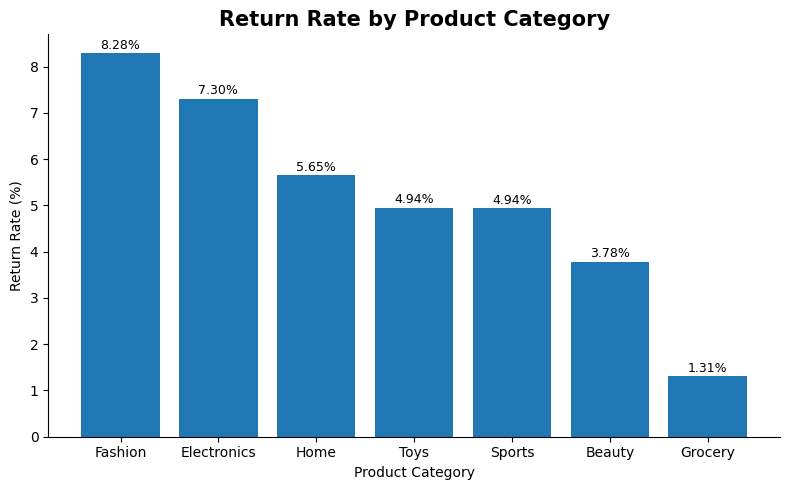

In [42]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    category_returns.index,
    category_returns["return_rate"]
)

plt.title("Return Rate by Product Category", fontsize=15, weight="bold")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{height:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/return_rate_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- **Fashion** has the highest return rate at **8.28%**, followed by **Electronics** at **7.30%**, both significantly exceeding the overall return rate of **5.52%**.
- **Home** products have a return rate of **5.65%**, which is close to the overall average.
- **Toys** and **Sports** exhibit similar return rates of approximately **4.94%**, indicating relatively lower return frequencies.
- **Beauty** products have a comparatively low return rate (**3.78%**), while **Grocery** has the lowest return rate at **1.31%**.

### Business Insight

The analysis indicates that return behavior varies considerably across product categories. Fashion and Electronics contribute disproportionately to product returns, suggesting potential issues related to product fit, customer expectations, product descriptions, or quality. In contrast, Grocery products exhibit a very low return rate, indicating greater purchase certainty and customer satisfaction.

### Recommendation

The business should prioritize return reduction initiatives for **Fashion** and **Electronics** by improving product descriptions, enhancing size and specification accuracy, strengthening quality control, and providing richer product images or customer reviews. Targeted improvements in these categories are likely to produce the greatest reduction in overall return rates.

## 3.2 Return Rate by Region

This analysis compares return rates across different geographical regions to determine whether customer location influences product return behavior.

Identifying regional differences in return rates can help businesses optimize logistics, improve customer experience, and implement region-specific return reduction strategies.

In [43]:
region_returns = (
    df.groupby("region")
      .agg(
          total_orders=("returned", "count"),
          returned_orders=("returned", "sum")
      )
)

region_returns["return_rate"] = (
    region_returns["returned_orders"] /
    region_returns["total_orders"] * 100
)

region_returns = region_returns.sort_values(
    "return_rate",
    ascending=False
)

region_returns

,total_orders,returned_orders,return_rate
region,,,
East,6904,408,5.909618
South,7584,431,5.683017
West,6808,371,5.449471
North,7572,406,5.361859
Central,5632,287,5.095881


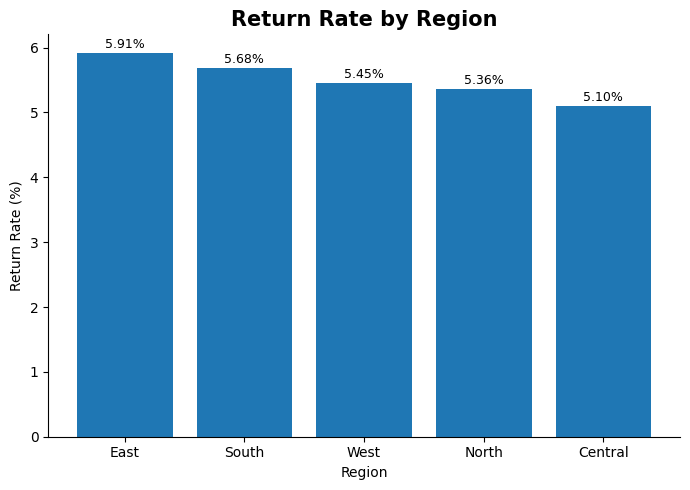

In [44]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    region_returns.index,
    region_returns["return_rate"]
)

plt.title("Return Rate by Region", fontsize=15, weight="bold")
plt.xlabel("Region")
plt.ylabel("Return Rate (%)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.08,
        f"{height:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/return_rate_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- The **East** region has the highest return rate at **5.91%**, followed by the **South** (**5.68%**).
- The **West** (**5.45%**) and **North** (**5.36%**) regions have return rates close to the overall average (**5.52%**).
- The **Central** region records the lowest return rate at **5.10%**.
- Overall, return rates vary by **less than one percentage point** across all regions, indicating relatively consistent return behavior regardless of customer location.

### Business Insight

Unlike product category, **region does not appear to be a strong driver of product returns**. The small variation in return rates suggests that the company's logistics, customer service, and fulfillment processes are performing consistently across different geographical regions.

### Recommendation

Although no major regional issues are evident, the **East** region should be monitored to understand why its return rate is slightly higher than other regions. Future analysis could investigate whether specific product categories or customer segments within the East contribute disproportionately to returns rather than implementing region-wide interventions.

## 3.3 Return Rate by Payment Method

This analysis compares return rates across different payment methods to determine whether purchasing behavior varies based on how customers complete their transactions.

Understanding return patterns by payment method can help identify customer segments that may require targeted interventions or improvements in the purchasing experience.

In [45]:
payment_returns = (
    df.groupby("payment_method")
      .agg(
          total_orders=("returned", "count"),
          returned_orders=("returned", "sum")
      )
)

payment_returns["return_rate"] = (
    payment_returns["returned_orders"] /
    payment_returns["total_orders"] * 100
)

payment_returns = payment_returns.sort_values(
    "return_rate",
    ascending=False
)

payment_returns

,total_orders,returned_orders,return_rate
payment_method,,,
PayPal,3444,199,5.778165
Debit Card,8505,482,5.667255
Credit Card,12170,675,5.546426
UPI,4156,224,5.389798
Wallet,2065,111,5.375303
COD,4160,212,5.096154


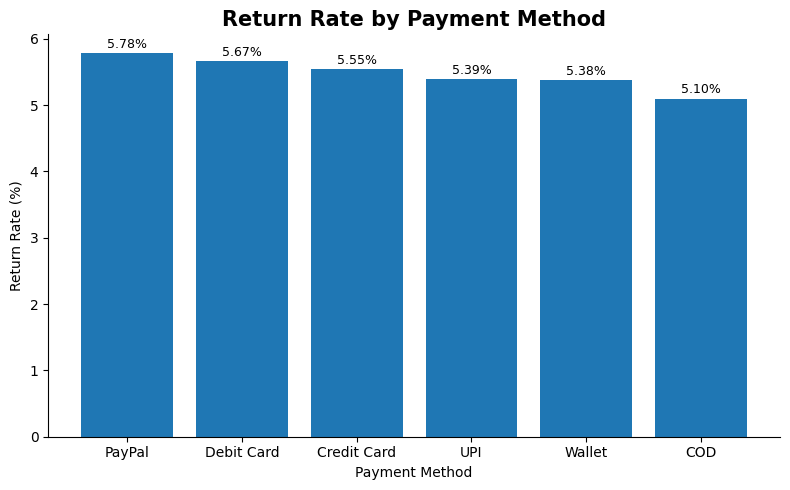

In [47]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    payment_returns.index,
    payment_returns["return_rate"]
)

plt.title("Return Rate by Payment Method", fontsize=15, weight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Return Rate (%)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.08,
        f"{height:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/return_rate_by_payment_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- **PayPal** records the highest return rate at **5.78%**, followed closely by **Debit Card** (**5.67%**) and **Credit Card** (**5.55%**).
- **UPI** (**5.39%**) and **Wallet** (**5.38%**) have return rates slightly below the overall average of **5.52%**.
- **Cash on Delivery (COD)** has the lowest return rate at **5.10%**.
- Overall, return rates across payment methods differ by **less than 0.7 percentage points**, indicating only minor variation in return behavior based on payment preference.

### Business Insight

The analysis suggests that **payment method is not a major driver of product returns**. Customers exhibit similar return behavior regardless of whether they pay online or choose Cash on Delivery, indicating that returns are more likely influenced by factors such as product characteristics or customer expectations than by the payment channel.

### Recommendation

No payment method requires targeted return reduction strategies based on the current data. Instead, business efforts should focus on higher-impact factors such as **product category, product quality, pricing, and product descriptions**, which are more likely to influence return behavior.

## 3.4 Return Rate by Customer Gender

This analysis compares return rates across different customer genders to determine whether purchasing and return behavior varies among customer segments.

Identifying demographic differences in return rates can help businesses understand whether targeted customer engagement or marketing strategies are needed.

In [48]:
gender_returns = (
    df.groupby("customer_gender")
      .agg(
          total_orders=("returned", "count"),
          returned_orders=("returned", "sum")
      )
)

gender_returns["return_rate"] = (
    gender_returns["returned_orders"] /
    gender_returns["total_orders"] * 100
)

gender_returns = gender_returns.sort_values(
    "return_rate",
    ascending=False
)

gender_returns

,total_orders,returned_orders,return_rate
customer_gender,,,
Female,16818,945,5.618980
Male,16310,887,5.438381
Other,1372,71,5.174927


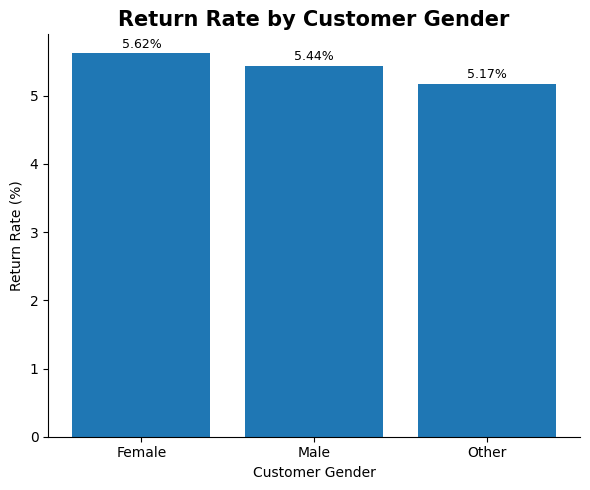

In [49]:
plt.figure(figsize=(6,5))

bars = plt.bar(
    gender_returns.index,
    gender_returns["return_rate"]
)

plt.title("Return Rate by Customer Gender", fontsize=15, weight="bold")
plt.xlabel("Customer Gender")
plt.ylabel("Return Rate (%)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.08,
        f"{height:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/return_rate_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- **Female** customers have the highest return rate at **5.62%**, followed closely by **Male** customers at **5.44%**.
- Customers identifying as **Other** have the lowest return rate at **5.17%**.
- The difference between the highest and lowest return rates is only **0.44 percentage points**, indicating minimal variation in return behavior across customer genders.
- Overall, return rates remain close to the dataset's average return rate (**5.52%**), suggesting a consistent pattern across all gender groups.

### Business Insight

Customer gender does not appear to have a significant influence on product return behavior. The similarity in return rates indicates that returns are more likely driven by product-related or order-related factors rather than customer demographics.

### Recommendation

No gender-specific return reduction strategies are recommended based on the current analysis. Business efforts should instead focus on higher-impact factors such as product category, pricing, product quality, and customer expectations, which exhibit greater variation in return rates.

## 3.5 Return Rate by Age Group

This analysis compares return rates across different customer age groups to determine whether purchasing and return behavior varies by age.

Understanding return patterns across age groups can help businesses identify customer segments that may benefit from improved product information, personalized recommendations, or targeted customer support.

In [50]:
age_returns = (
    df.groupby("age_group", observed=False)
      .agg(
          total_orders=("returned", "count"),
          returned_orders=("returned", "sum")
      )
)

age_returns["return_rate"] = (
    age_returns["returned_orders"] /
    age_returns["total_orders"] * 100
)

age_returns = age_returns.sort_values(
    "return_rate",
    ascending=False
)

age_returns

,total_orders,returned_orders,return_rate
age_group,,,
36-45,6678,396,5.929919
18-25,5298,290,5.473764
60+,5945,324,5.449958
26-35,6678,360,5.390836
46-60,9901,533,5.383295


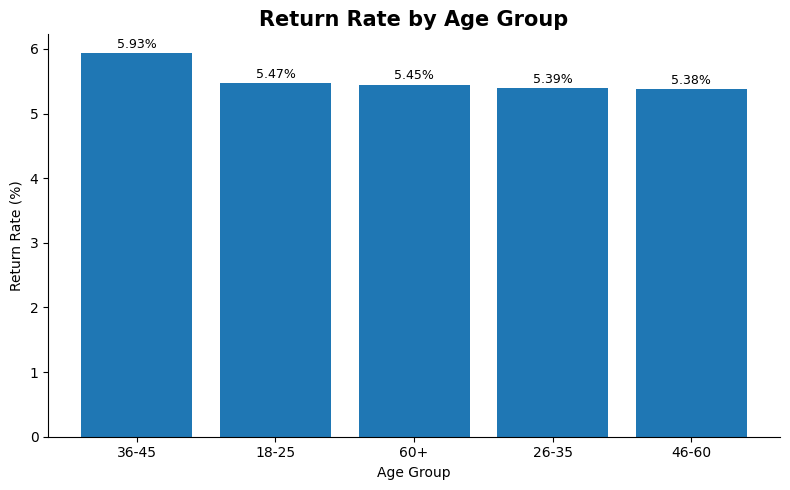

In [51]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    age_returns.index.astype(str),
    age_returns["return_rate"]
)

plt.title("Return Rate by Age Group", fontsize=15, weight="bold")
plt.xlabel("Age Group")
plt.ylabel("Return Rate (%)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.08,
        f"{height:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/return_rate_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Customers aged **36–45** have the highest return rate at **5.93%**, slightly above the overall average return rate of **5.52%**.
- The **18–25** (**5.47%**), **60+** (**5.45%**), **26–35** (**5.39%**), and **46–60** (**5.38%**) age groups all exhibit very similar return rates.
- The difference between the highest and lowest return rates is only **0.55 percentage points**, indicating relatively consistent return behavior across all age groups.

### Business Insight

Age does not appear to be a strong determinant of product returns in this dataset. The similarity in return rates across age groups suggests that returns are driven more by product-specific or order-specific factors than by customer age.

### Recommendation

No age-specific return reduction strategies are recommended based on the current findings. Future efforts should focus on high-impact factors such as product category, pricing, delivery performance, and product quality, which are more likely to influence return behavior.

## 3.6 Product Price vs Return Status

This analysis compares product prices between returned and non-returned orders to determine whether higher-priced products are more likely to be returned.

A boxplot is used to compare the distribution, median, spread, and presence of outliers across the two groups.

In [53]:
df.groupby("returned")["price"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
returned,,,,,,,,
0,32597.0,117.89,194.11,1.01,16.37,44.73,128.96,2930.47
1,1903.0,145.12,218.42,1.11,23.21,64.95,166.93,2211.69


<Figure size 700x500 with 0 Axes>

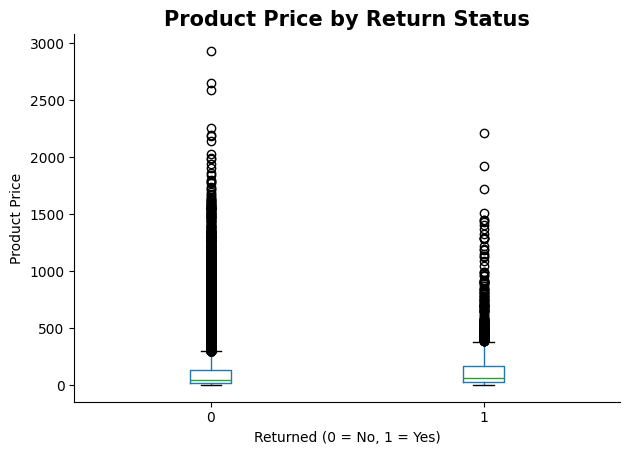

In [54]:
plt.figure(figsize=(7,5))

df.boxplot(
    column="price",
    by="returned",
    grid=False
)

plt.title("Product Price by Return Status", fontsize=15, weight="bold")
plt.suptitle("")  # removes pandas default title
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Product Price")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/price_vs_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Returned orders have a higher average product price (**₹145.12**) compared to non-returned orders (**₹117.89**).
- The median product price for returned orders (**₹64.95**) is also considerably higher than that of non-returned orders (**₹44.73**), indicating that the difference is consistent across typical orders and is not driven solely by a few expensive products.
- The interquartile range (Q1–Q3) for returned orders (**₹23.21–₹166.93**) is shifted upward compared to non-returned orders (**₹16.37–₹128.96**), suggesting that returned products tend to be more expensive across the entire distribution.
- Both groups contain high-priced outliers, reflecting the presence of premium products in the dataset.

### Business Insight

Higher-priced products appear to be returned more frequently than lower-priced products. Customers may have higher expectations for expensive purchases, making them more likely to initiate returns if the product does not meet expectations, differs from its description, or exhibits quality issues.

### Recommendation

The business should strengthen quality assurance, provide more detailed product descriptions, high-quality images, and comprehensive specifications for higher-priced products. Reducing uncertainty before purchase can help lower return rates for premium items, where the financial impact of returns is greater.

In [55]:
from scipy.stats import mannwhitneyu

returned = df[df["returned"] == 1]["price"]
not_returned = df[df["returned"] == 0]["price"]

stat, p = mannwhitneyu(returned, not_returned)

print(f"P-value: {p:.6f}")

P-value: 0.000000


### Statistical Validation

A Mann–Whitney U test was performed to compare product prices between returned and non-returned orders.

- **P-value:** < 0.001

Since the p-value is substantially below the 0.05 significance level, the difference in product price distributions between the two groups is **statistically significant**. This provides strong evidence that returned orders tend to involve higher-priced products than non-returned orders.

## 3.7 Total Order Value vs Return Status

This analysis compares total order values between returned and non-returned orders to determine whether higher-value purchases are associated with an increased likelihood of returns.

Since returned orders directly impact revenue, understanding this relationship helps quantify the financial risk associated with customer returns.

In [56]:
df.groupby("returned")["total_amount"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
returned,,,,,,,,
0,32597.0,168.01,355.89,0.82,19.32,55.70,166.04,12931.80
1,1903.0,204.29,382.61,1.73,27.76,78.46,216.70,5150.28


<Figure size 700x500 with 0 Axes>

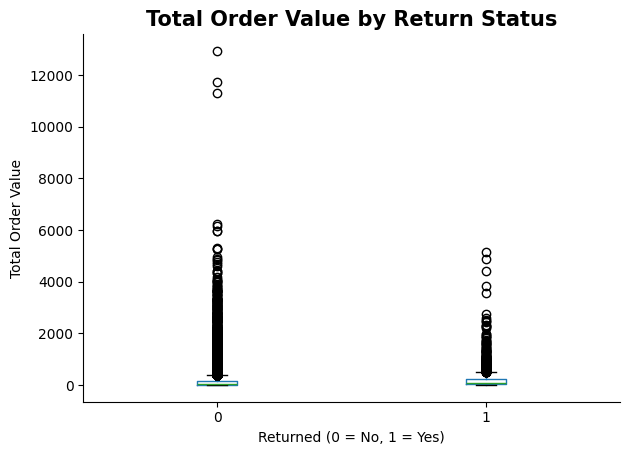

In [57]:
plt.figure(figsize=(7,5))

df.boxplot(
    column="total_amount",
    by="returned",
    grid=False
)

plt.title("Total Order Value by Return Status", fontsize=15, weight="bold")
plt.suptitle("")
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Total Order Value")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/total_order_value_vs_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Returned orders have a higher average order value (**₹204.29**) compared to non-returned orders (**₹168.01**).
- The median order value for returned orders (**₹78.46**) is substantially higher than that of non-returned orders (**₹55.70**), indicating that the difference is consistent across typical orders and is not driven solely by a small number of expensive purchases.
- The interquartile range (Q1–Q3) for returned orders (**₹27.76–₹216.70**) is noticeably higher than that of non-returned orders (**₹19.32–₹166.04**), showing that returned orders generally have greater monetary value throughout the distribution.
- Both groups contain high-value outliers, reflecting occasional large purchases, but the overall distribution for returned orders is shifted toward higher order values.

### Business Insight

Higher-value orders are more likely to be returned than lower-value orders. Since these orders represent a larger portion of revenue, each return has a greater financial impact on the business through lost sales, reduced profitability, and additional reverse logistics costs.

### Recommendation

The business should prioritize return prevention for high-value orders by providing detailed product information, high-quality images, accurate specifications, and proactive customer support before purchase. Reducing returns among high-value orders can significantly lower revenue loss and improve overall profitability.

In [59]:
from scipy.stats import mannwhitneyu

returned = df[df["returned"] == 1]["total_amount"]
not_returned = df[df["returned"] == 0]["total_amount"]

stat, p = mannwhitneyu(returned, not_returned)

print(f"Mann-Whitney U Statistic: {stat}")
print(f"P-value: {p:.6f}")

Mann-Whitney U Statistic: 34752007.0
P-value: 0.000000


### Statistical Validation

A Mann–Whitney U test was performed to compare total order values between returned and non-returned orders.

- **P-value:** < 0.001

Since the p-value is well below the 0.05 significance level, the difference in total order value distributions between returned and non-returned orders is **statistically significant**. This provides strong evidence that returned orders tend to have higher monetary value than non-returned orders.

## 3.8 Profit Margin vs Return Status

This analysis compares the profit margins of returned and non-returned orders to determine whether more profitable products are also more likely to be returned.

Understanding this relationship helps quantify the impact of returns on business profitability and supports better inventory and pricing decisions.

In [60]:
df.groupby("returned")["profit_margin"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
returned,,,,,,,,
0,32597.0,27.86,53.4,-6.20,1.38,10.35,32.66,1536.17
1,1903.0,32.48,52.3,-5.19,3.88,15.48,40.32,605.85


<Figure size 700x500 with 0 Axes>

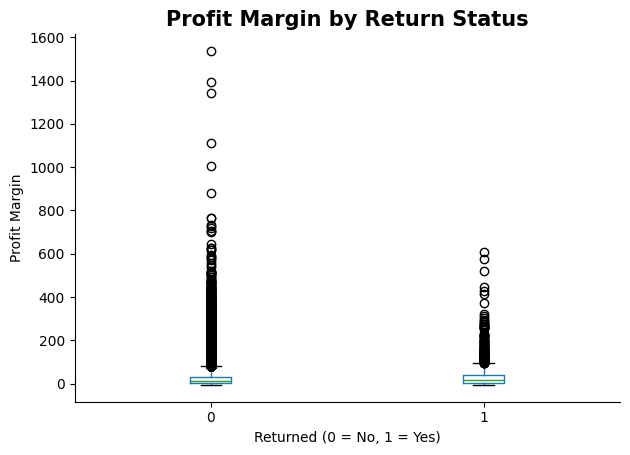

In [61]:
plt.figure(figsize=(7,5))

df.boxplot(
    column="profit_margin",
    by="returned",
    grid=False
)

plt.title("Profit Margin by Return Status", fontsize=15, weight="bold")
plt.suptitle("")
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Profit Margin")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/profit_margin_vs_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Returned orders have a higher average profit margin (**₹32.48**) compared to non-returned orders (**₹27.86**).
- The median profit margin for returned orders (**₹15.48**) is notably higher than that of non-returned orders (**₹10.35**), indicating that the difference is consistent across typical orders rather than being driven by a few extreme values.
- The interquartile range (Q1–Q3) for returned orders (**₹3.88–₹40.32**) is shifted upward compared to non-returned orders (**₹1.38–₹32.66**), suggesting that returned orders generally involve products with higher profit margins.
- Both groups contain outliers, but the overall distribution indicates that products generating greater profits are also more frequently represented among returned orders.

### Business Insight

Returns disproportionately affect higher-margin products, increasing the financial impact beyond the loss of sales revenue alone. When profitable products are returned, the business loses valuable contribution margins while also incurring additional operational costs associated with processing returns.

### Recommendation

The business should prioritize return reduction strategies for high-margin products by strengthening quality assurance, improving product descriptions, and providing accurate specifications before purchase. Protecting high-margin sales can have a greater positive impact on overall profitability than focusing solely on reducing the number of returns.

In [62]:
from scipy.stats import mannwhitneyu

returned = df[df["returned"] == 1]["profit_margin"]
not_returned = df[df["returned"] == 0]["profit_margin"]

stat, p = mannwhitneyu(returned, not_returned)

print(f"Mann-Whitney U Statistic: {stat}")
print(f"P-value: {p:.6f}")

Mann-Whitney U Statistic: 34949800.0
P-value: 0.000000


### Statistical Validation

A Mann–Whitney U test was performed to compare profit margins between returned and non-returned orders.

- **P-value:** < 0.001

Since the p-value is well below the 0.05 significance level, the difference in profit margin distributions between returned and non-returned orders is **statistically significant**. This indicates that returned orders tend to involve products with higher profit margins.

## 3.9 Delivery Days vs Return Status

This analysis compares delivery times between returned and non-returned orders to determine whether longer delivery durations are associated with an increased likelihood of product returns.

Delivery performance is a key aspect of customer experience and may influence customer satisfaction and purchasing decisions.

In [63]:
df.groupby("returned")["delivery_days"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
returned,,,,,,,,
0,32597.0,4.81,1.24,3.0,4.0,5.0,6.0,13.0
1,1903.0,4.84,1.24,3.0,4.0,5.0,6.0,10.0


<Figure size 700x500 with 0 Axes>

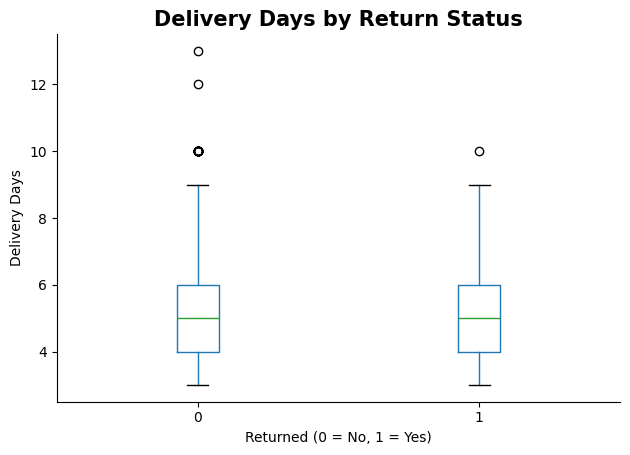

In [64]:
plt.figure(figsize=(7,5))

df.boxplot(
    column="delivery_days",
    by="returned",
    grid=False
)

plt.title("Delivery Days by Return Status", fontsize=15, weight="bold")
plt.suptitle("")
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Delivery Days")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/delivery_days_vs_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- The average delivery time is nearly identical for both groups, with non-returned orders averaging **4.81 days** and returned orders averaging **4.84 days**.
- Both groups have the same median delivery time of **5 days**, indicating that a typical customer experiences similar delivery durations regardless of whether the order is eventually returned.
- The interquartile range (Q1–Q3) is identical for both groups (**4–6 days**), showing that the spread of delivery times is highly consistent.
- Overall, the distributions of delivery days for returned and non-returned orders overlap substantially, suggesting minimal practical differences in delivery performance.

### Business Insight

Delivery time does not appear to be a meaningful driver of product returns in this dataset. Most customers, regardless of whether they returned their purchase, received their orders within a similar timeframe. This suggests that factors such as product quality, product expectations, and product characteristics have a greater influence on return behavior than delivery duration.

### Recommendation

Based on the current data, improving delivery speed alone is unlikely to produce a significant reduction in return rates. Business efforts should instead prioritize improvements in product quality, product descriptions, and customer expectations, while continuing to maintain the existing delivery performance.

In [65]:
from scipy.stats import mannwhitneyu

returned = df[df["returned"] == 1]["delivery_days"]
not_returned = df[df["returned"] == 0]["delivery_days"]

stat, p = mannwhitneyu(returned, not_returned)

print(f"Mann-Whitney U Statistic: {stat}")
print(f"P-value: {p:.6f}")

Mann-Whitney U Statistic: 31352797.0
P-value: 0.410817


### Statistical Validation

A Mann–Whitney U test was performed to compare delivery times between returned and non-returned orders.

- **P-value:** 0.411

Since the p-value is greater than the 0.05 significance level, there is **no statistically significant difference** in delivery times between returned and non-returned orders. This confirms that delivery duration is not associated with product return behavior in the current dataset.

## 3.10 Discount vs Return Status

This analysis compares discounts offered on returned and non-returned orders to determine whether heavily discounted purchases are associated with a higher likelihood of returns.

Understanding this relationship helps businesses evaluate whether discounting strategies influence customer return behavior.

In [66]:
df.groupby("returned")["discount"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
returned,,,,,,,,
0,32597.0,0.05,0.07,0.0,0.0,0.0,0.1,0.3
1,1903.0,0.05,0.07,0.0,0.0,0.0,0.1,0.3


<Figure size 700x500 with 0 Axes>

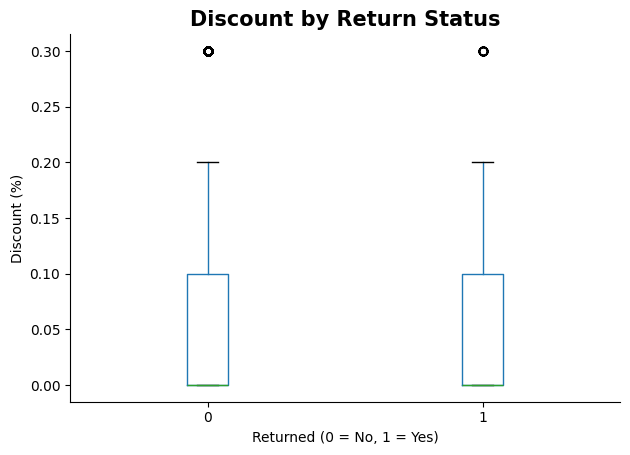

In [67]:
plt.figure(figsize=(7,5))

df.boxplot(
    column="discount",
    by="returned",
    grid=False
)

plt.title("Discount by Return Status", fontsize=15, weight="bold")
plt.suptitle("")
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Discount (%)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/discount_vs_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- Both returned and non-returned orders have an identical average discount of **5%**.
- The median discount is **0%** for both groups, indicating that more than half of all orders were placed without any discount, regardless of return status.
- The interquartile range (Q1–Q3) is identical (**0%–10%**) for both returned and non-returned orders, showing nearly identical discount distributions.
- Overall, the boxplots overlap almost completely, suggesting that discount levels are similar regardless of whether an order is returned.

### Business Insight

The analysis indicates that discounting does not meaningfully influence product return behavior in this dataset. Customers receiving larger discounts do not appear to return products more frequently than those purchasing at full price.

### Recommendation

The current discount strategy does not appear to increase product returns and therefore does not require modification from a return management perspective. Instead, the business should continue focusing on higher-impact factors such as product category, product quality, and high-value purchases, which exhibit much stronger relationships with returns.

In [68]:
from scipy.stats import mannwhitneyu

returned = df[df["returned"] == 1]["discount"]
not_returned = df[df["returned"] == 0]["discount"]

stat, p = mannwhitneyu(returned, not_returned)

print(f"Mann-Whitney U Statistic: {stat}")
print(f"P-value: {p:.6f}")

Mann-Whitney U Statistic: 31125601.0
P-value: 0.775365


### Statistical Validation

A Mann–Whitney U test was performed to compare discount distributions between returned and non-returned orders.

- **P-value:** 0.775

Since the p-value is greater than the 0.05 significance level, there is **no statistically significant difference** in discount levels between returned and non-returned orders. This confirms that discounts are not associated with product return behavior in the current dataset.

## 3.11 Summary of Bivariate Analysis

The bivariate analysis identified several factors associated with product returns.

### Key Findings

- **Product category** is the strongest categorical predictor of returns, with **Fashion (8.28%)** and **Electronics (7.30%)** exhibiting the highest return rates.
- Returned orders tend to involve **higher-priced products**, **higher order values**, and **higher profit margins**, with all differences found to be statistically significant (**p < 0.001**).
- **Region**, **payment method**, **customer gender**, and **age group** show only minor variation in return rates, indicating that customer demographics and payment preferences have limited influence on returns.
- **Delivery days** (**p = 0.411**) and **discount levels** (**p = 0.775**) do not show statistically significant differences between returned and non-returned orders.

Overall, the findings suggest that **product characteristics and order value are more important drivers of returns than customer demographics, payment behavior, pricing promotions, or delivery performance.**

# 4. Return Reason Analysis

While the previous section identified factors associated with higher return rates, this section focuses exclusively on returned orders to understand **why products are returned** and **which return reasons have the greatest financial impact**.

These insights can help the business prioritize operational improvements that reduce costly product returns.

## 4.1 Distribution of Return Reasons

This analysis examines the frequency of each return reason to identify the most common causes of product returns.

Understanding why customers return products enables businesses to prioritize improvements that address the largest sources of customer dissatisfaction.

In [69]:
return_reason_counts = (
    df[df["returned"] == 1]["return_reason"]
    .value_counts()
)

return_reason_counts

return_reason
Not as described      490
No longer needed      481
Defective             465
Missing/Wrong item    439
Slow delivery          28
Name: count, dtype: int64

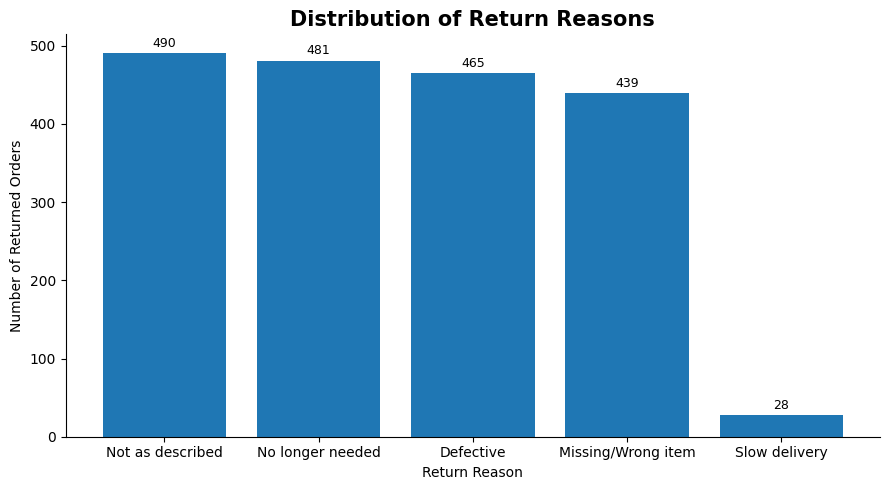

In [71]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    return_reason_counts.index,
    return_reason_counts.values
)

plt.title("Distribution of Return Reasons", fontsize=15, weight="bold")
plt.xlabel("Return Reason")
plt.ylabel("Number of Returned Orders")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 8,
        f"{int(height)}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/return_reason_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- **Not as described** is the most common return reason, accounting for **490 returned orders**, closely followed by **No longer needed** (**481**) and **Defective** (**465**).
- **Missing/Wrong item** is also a major contributor, with **439** returned orders.
- **Slow delivery** accounts for only **28** returned orders, making it the least common return reason by a wide margin.
- The top four return reasons have very similar frequencies, indicating that product-related issues contribute far more to returns than logistics-related issues.

### Business Insight

Most returns are driven by **product-related factors** rather than delivery performance. Issues such as inaccurate product descriptions, product defects, incorrect order fulfillment, and changing customer preferences account for nearly all returned orders, while delivery delays contribute only a small fraction.

### Recommendation

The business should prioritize initiatives that improve product accuracy and quality, including:

- Enhancing product descriptions and images to better match customer expectations.
- Strengthening quality control processes to reduce defective products.
- Improving warehouse picking and packing accuracy to minimize incorrect shipments.
- Monitoring customer feedback to identify products with consistently high return volumes and address recurring issues.

Since slow delivery represents only a small proportion of returns, investments in reducing return rates are likely to deliver greater value when focused on product quality and fulfillment accuracy rather than delivery speed.

## 4.2 Financial Impact by Return Reason

This analysis evaluates the financial consequences of different return reasons by comparing both the revenue lost and the associated profit impact.

While some return reasons occur with similar frequency, their financial impact may differ depending on the value and profitability of the returned products. Analyzing both metrics together helps prioritize improvement efforts based on overall business impact.

In [72]:
financial_impact = (
    df[df["returned"] == 1]
    .groupby("return_reason")
    .agg(
        revenue_loss=("total_amount", "sum"),
        profit_impact=("profit_margin", "sum")
    )
    .sort_values("revenue_loss", ascending=False)
    .round(2)
)

financial_impact

,revenue_loss,profit_impact
return_reason,,
Not as described,105010.39,16216.48
Defective,94436.54,14737.16
Missing/Wrong item,94348.82,15308.98
No longer needed,89302.33,14678.08
Slow delivery,5657.89,864.76


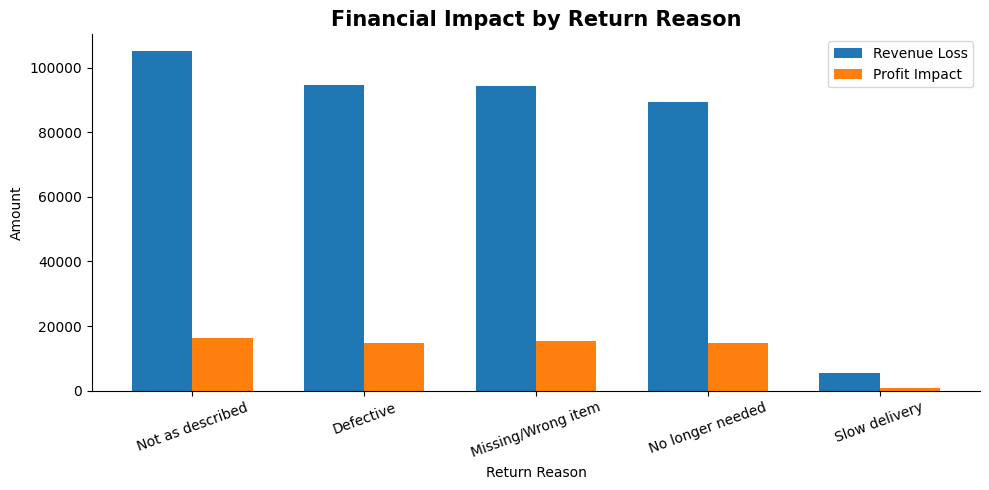

In [73]:
import numpy as np

x = np.arange(len(financial_impact))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x - width/2,
    financial_impact["revenue_loss"],
    width,
    label="Revenue Loss"
)

plt.bar(
    x + width/2,
    financial_impact["profit_impact"],
    width,
    label="Profit Impact"
)

plt.xticks(x, financial_impact.index, rotation=20)

plt.title("Financial Impact by Return Reason", fontsize=15, weight="bold")
plt.xlabel("Return Reason")
plt.ylabel("Amount")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend()

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/financial_impact_by_return_reason.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- **Not as described** has the highest financial impact, resulting in **₹105,010.39** in revenue loss and **₹16,216.48** in lost profit, making it the costliest return reason.
- **Defective**, **Missing/Wrong item**, and **No longer needed** all contribute substantially to financial losses, each resulting in approximately **₹89K–₹94K** in revenue loss and **₹14.7K–₹15.3K** in profit impact.
- **Missing/Wrong item** generates a slightly higher profit impact than **Defective**, despite a similar revenue loss, indicating that incorrect shipments affect relatively higher-margin products.
- **Slow delivery** has a minimal financial impact, contributing only **₹5,657.89** in revenue loss and **₹864.76** in profit loss.

### Business Insight

The overwhelming majority of financial losses arise from **product-related and fulfillment-related issues**, rather than logistics. Inaccurate product descriptions, product defects, incorrect shipments, and unmet customer expectations account for nearly all lost revenue and profit, highlighting where operational improvements will deliver the greatest business value.

### Recommendation

To minimize financial losses, the business should prioritize:

- Improving product descriptions and images to reduce "Not as described" returns.
- Strengthening quality assurance processes to reduce defective products.
- Enhancing warehouse picking and packing accuracy to prevent incorrect shipments.
- Monitoring products with consistently high financial impact to identify recurring quality or fulfillment issues.

Since **Slow delivery** contributes only a small fraction of the overall financial loss, investments aimed solely at faster delivery are unlikely to reduce returns as effectively as improvements in product quality and fulfillment accuracy.

# 4. Multivariate Analysis

The previous analyses examined one or two variables at a time. This section explores relationships among multiple variables simultaneously to uncover broader business patterns and interactions that influence product returns.

The objective is to identify combinations of factors that contribute to return behavior and quantify relationships between operational, financial, and customer-related variables.

## 4.1 Correlation Analysis

Correlation analysis measures the strength and direction of relationships between numerical variables.

A correlation heatmap helps identify variables that move together and highlights potential drivers of order value, profitability, and product returns.

In [74]:
import seaborn as sns

corr_cols = [
    "price",
    "quantity",
    "discount",
    "shipping_cost",
    "delivery_days",
    "profit_margin",
    "total_amount",
    "returned"
]

corr = df[corr_cols].corr(numeric_only=True)

corr.round(2)

,price,quantity,discount,shipping_cost,delivery_days,profit_margin,total_amount,returned
price,1.00,0.01,0.01,0.65,0.01,0.68,0.80,0.03
quantity,0.01,1.00,-0.01,0.28,0.01,0.39,0.30,0.00
discount,0.01,-0.01,1.00,-0.05,0.00,-0.05,-0.03,-0.00
shipping_cost,0.65,0.28,-0.05,1.00,0.01,0.62,0.60,0.05
delivery_days,0.01,0.01,0.00,0.01,1.00,0.01,0.01,0.00
profit_margin,0.68,0.39,-0.05,0.62,0.01,1.00,0.89,0.02
total_amount,0.80,0.30,-0.03,0.60,0.01,0.89,1.00,0.02
returned,0.03,0.00,-0.00,0.05,0.00,0.02,0.02,1.00


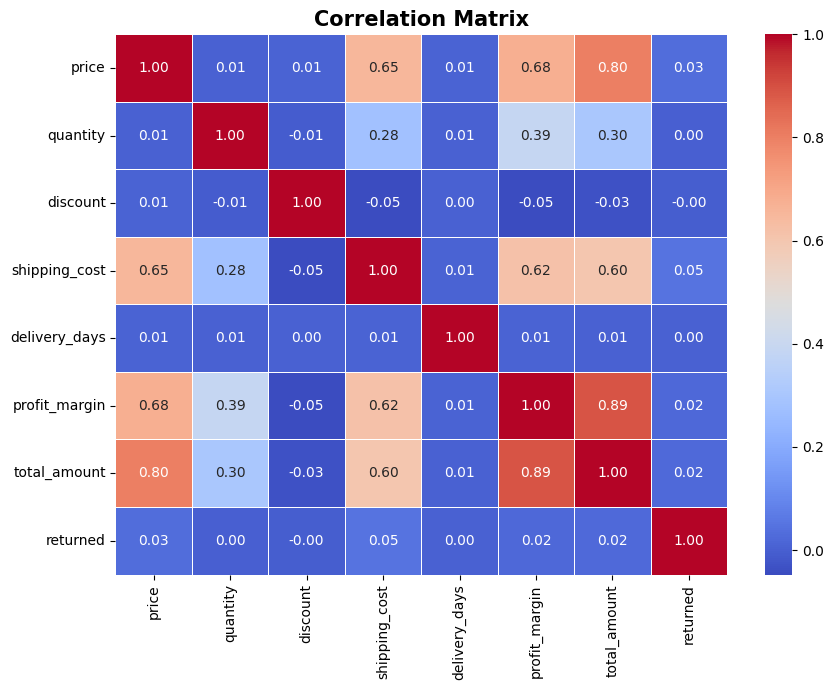

In [75]:
plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- **Total Order Value** and **Profit Margin** exhibit the strongest positive correlation (**0.89**), indicating that higher-value orders generally generate greater profits.
- **Product Price** has a strong positive correlation with **Total Order Value** (**0.80**) and **Profit Margin** (**0.68**), suggesting that more expensive products contribute substantially to both revenue and profitability.
- **Shipping Cost** is moderately correlated with **Product Price** (**0.65**), **Profit Margin** (**0.62**), and **Total Order Value** (**0.60**), indicating that higher-value orders typically incur higher shipping costs.
- **Quantity** shows a moderate positive correlation with **Profit Margin** (**0.39**) and **Total Order Value** (**0.30**), reflecting the expected increase in revenue and profit as customers purchase more items.
- **Discount** has only a weak negative correlation with **Profit Margin** (**−0.05**) and **Total Order Value** (**−0.03**), suggesting that discounts have minimal influence on overall order value and profitability.
- **Delivery Days** exhibits negligible correlations with all variables, indicating that delivery time operates independently of pricing, profitability, and customer purchasing behavior.
- The **Returned** variable shows very weak linear correlations with all numerical variables (maximum correlation **0.05**), suggesting that return behavior cannot be explained by any single numerical feature alone.

## 4.2 Return Rate by Product Category and Region

This analysis examines how return rates vary across both product categories and geographic regions.

Combining these two dimensions helps identify whether certain categories consistently experience higher returns across regions or whether regional factors influence return behavior.

In [76]:
heatmap = (
    df.groupby(
        ["category", "region"],
        observed=False
    )["returned"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)

heatmap

region,Central,East,North,South,West
category,,,,,
Beauty,3.99,3.62,3.78,4.03,3.46
Electronics,6.68,8.48,6.97,7.45,6.74
Fashion,7.09,8.58,9.11,8.86,7.45
Grocery,0.89,1.39,1.49,1.15,1.54
Home,6.37,6.18,4.61,5.54,5.79
Sports,4.40,4.56,5.39,5.03,5.18
Toys,4.31,5.28,4.23,5.10,5.83


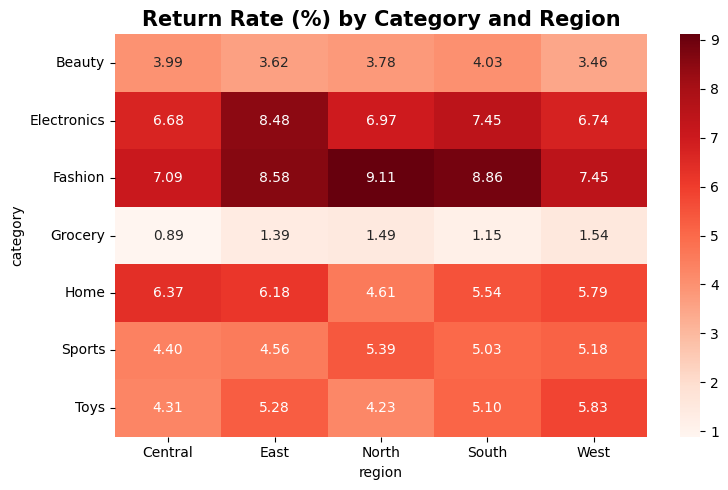

In [77]:
plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title(
    "Return Rate (%) by Category and Region",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/category_region_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- **Fashion** shows the highest return rates across all regions (7.09%–9.11%), with the **North region (9.11%)** being the highest overall.
- **Electronics** also records high return rates, especially in the **East region (8.48%)**, indicating possible issues with product quality or mismatch in expectations.
- **Grocery** has the lowest return rates across all regions (0.89%–1.54%), showing strong product reliability and clear customer expectations.
- The **East region** consistently shows higher return rates across multiple categories, indicating a possible regional operational or fulfillment issue.
- **Beauty, Sports, and Toys** show moderate and relatively stable return patterns compared to Fashion and Electronics.

### Business Insight

Return behavior is strongly driven by the interaction of **category and region**, rather than either factor alone. High-risk categories like Fashion and Electronics consistently show elevated return rates across all regions, while Grocery demonstrates that well-defined expectations significantly reduce returns. The East region appears to be a consistent hotspot for higher returns.

### Recommendation

- Focus on reducing returns in **Fashion and Electronics**, as they are the highest-risk categories.
- Investigate operational and fulfillment issues in the **East region**.
- Improve product clarity in Fashion (size guides, images, descriptions).
- Use Grocery as a benchmark for low-return product design.
- Implement region-wise return tracking to identify problem areas early.

## 4.3 Average Order Value by Product Category and Return Status

This analysis compares the average order value across product categories for returned and non-returned orders.

It helps identify categories where returned purchases represent particularly high financial exposure.

In [78]:
avg_order = (
    df.groupby(
        ["category", "returned"],
        observed=False
    )["total_amount"]
    .mean()
    .round(2)
    .unstack()
)

avg_order.columns = [
    "Not Returned",
    "Returned"
]

avg_order

,Not Returned,Returned
category,,
Beauty,37.18,40.27
Electronics,536.59,543.46
Fashion,75.65,72.67
Grocery,20.20,20.87
Home,196.27,198.69
Sports,150.95,151.99
Toys,31.27,27.42


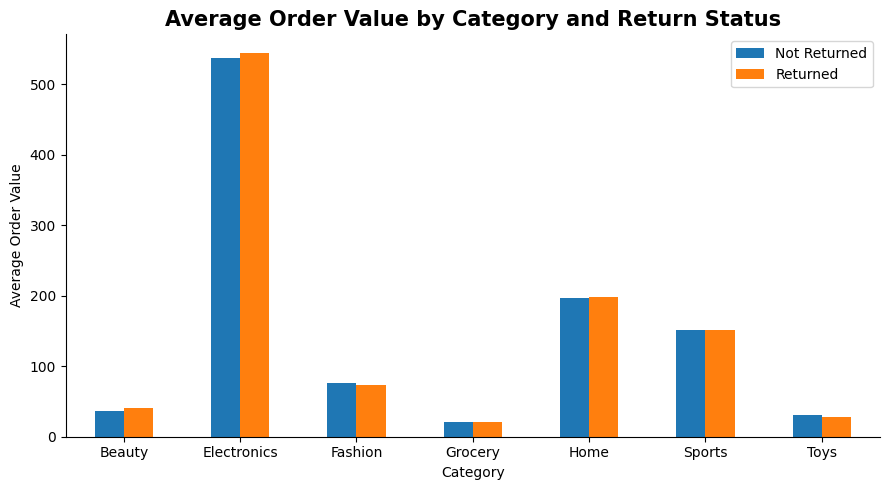

In [79]:
avg_order.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title(
    "Average Order Value by Category and Return Status",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Category")
plt.ylabel("Average Order Value")

plt.xticks(rotation=0)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/category_order_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

- **Electronics** has the highest average order value in both returned (₹543.46) and not returned (₹536.59) categories, indicating high-value transactions are concentrated here.
- In most categories (**Electronics, Home, Sports, Grocery, Beauty**), returned orders have a slightly higher average order value than non-returned orders, suggesting that higher-value purchases are marginally more prone to returns.
- **Fashion** shows a reverse trend, where returned orders (₹72.67) are lower in value than non-returned orders (₹75.65), indicating that lower-value fashion items are more frequently returned.
- **Toys** also shows a noticeable drop in returned order value (₹27.42 vs ₹31.27), suggesting that lower-value toy purchases are more likely to be returned.

### Business Insight

Higher-value orders in most categories tend to have a slightly higher return tendency, especially in Electronics and Home categories. This suggests that financial exposure is greater not only because of return frequency but also because of the higher order value associated with returned items.

However, Fashion and Toys behave differently, where lower-value items are more frequently returned, indicating that return behavior is category-specific and not purely driven by order value.

### Recommendation

- Focus on **high-value categories like Electronics and Home**, as returns here create the greatest financial risk.
- Introduce **stricter quality checks and better product descriptions** for high-ticket items to reduce return probability.
- In Fashion and Toys, analyze **product-level issues (size, expectations, quality)** rather than order value, as returns are not driven by higher pricing.
- Implement **value-based return monitoring**, where high-value return orders are flagged for detailed root-cause analysis.

## 4.4 Profit Margin by Product Category

This analysis compares the distribution of profit margins across product categories.

Understanding profitability by category helps determine whether categories with high return rates are also the most profitable, allowing businesses to prioritize return reduction initiatives.

<Figure size 1000x500 with 0 Axes>

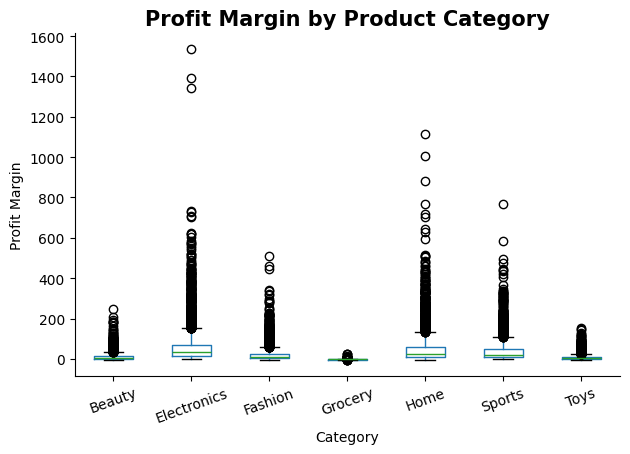

In [80]:
plt.figure(figsize=(10,5))

df.boxplot(
    column="profit_margin",
    by="category",
    grid=False
)

plt.suptitle("")

plt.title(
    "Profit Margin by Product Category",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Category")
plt.ylabel("Profit Margin")

plt.xticks(rotation=20)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "downloads/outputs/figures/profit_margin_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
df.groupby("category")["profit_margin"].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Beauty,4103.0,11.990395,18.897685,-3.23,1.4800,5.810,14.7850,246.47
Electronics,6180.0,55.723587,78.530121,-2.95,12.6475,31.720,68.3675,1536.17
Fashion,6254.0,20.597162,31.425385,-3.79,3.2150,10.575,25.8600,508.85
Grocery,4058.0,-2.264160,1.654435,-6.20,-3.2100,-2.410,-1.5500,26.47
Home,5487.0,47.864717,69.210936,-3.55,9.1000,25.990,59.5450,1112.25
Sports,4171.0,38.485114,51.748518,-2.89,7.7850,21.470,48.7300,765.28
Toys,4247.0,7.927773,13.765476,-4.34,0.2900,3.240,10.1700,153.34


### Interpretation

- **Electronics** has the highest average profit margin (**₹55.72**) with a wide spread (std: 78.53), indicating both highly profitable and highly variable transactions. It also contains extreme outliers (max: ₹1536.17), suggesting occasional very high-margin sales.
- **Home** and **Sports** categories also show strong average profit margins (**₹47.86** and **₹38.49**) with relatively high variability, indicating consistent profitability with occasional high-performing transactions.
- **Fashion** shows moderate profitability (**₹20.60**) but with a large spread, indicating inconsistent profit performance across orders.
- **Beauty** and **Toys** generate lower average margins (**₹11.99** and **₹7.93**) but remain relatively stable compared to high-value categories.
- **Grocery** is the only category with a **negative average profit margin (-₹2.26)**, indicating consistent losses, despite low variability. This suggests structural unprofitability in this category.

---

### Business Insight

Profitability is highly skewed across categories, with **Electronics, Home, and Sports driving the majority of profits**, while **Grocery consistently operates at a loss**. High-value categories also show significant variability, meaning profit is not stable and is influenced by occasional high-margin orders.

Importantly, categories with higher return activity (like Fashion and Electronics from earlier analysis) also show high profit variability, indicating that returns may be contributing to inconsistent profitability.

---

### Recommendation

- **Re-evaluate Grocery category strategy**, as it consistently generates negative profit margins and may require pricing, cost, or supplier restructuring.
- Focus on scaling **Electronics, Home, and Sports**, as they contribute the highest profitability potential.
- Reduce variability in **Fashion profitability** by addressing return-related issues and improving product consistency.
- Investigate extreme outliers in **Electronics and Home** to understand what drives exceptionally high margins and replicate those conditions.
- Implement category-wise profit monitoring to ensure loss-making categories are identified early.

## Key Findings (Multivariate Analysis)

- Strong positive relationships exist between **price, total order value, and profit margin**, indicating that high-value products are the primary drivers of profitability.
- **Returns show weak correlation with numerical variables**, suggesting that return behavior is influenced more by qualitative factors such as product quality, expectations, and fulfillment accuracy rather than price or delivery metrics.
- **Fashion and Electronics consistently exhibit higher return rates across all regions**, indicating structural issues in these categories rather than isolated regional effects.
- **Electronics, Home, and Sports generate the highest profit margins**, but also show high variability, making profitability inconsistent at the order level.
- **Grocery is consistently loss-making**, despite low return rates, indicating a structural profitability issue unrelated to returns.
- Higher-value orders tend to have a slightly higher likelihood of being returned, increasing financial risk in high-revenue categories.

## 5. Key Findings

- The majority of financial losses are driven by a small set of return reasons, with **“Not as described” alone contributing the highest revenue and profit loss**.
- **Product-related issues (quality, mismatch, defects, incorrect items)** are the primary drivers of returns, while **logistics (slow delivery)** has minimal impact.
- **Fashion and Electronics are the highest return-risk categories**, consistently showing elevated return rates across all regions.
- The **East region shows relatively higher return rates across multiple categories**, indicating possible regional operational inefficiencies.
- Returns are **not strongly correlated with numerical variables** such as price, discount, or delivery days, suggesting returns are driven by qualitative factors.
- High-value categories such as **Electronics, Home, and Sports generate the highest profits**, but also show variability in performance.
- **Grocery is consistently unprofitable**, despite having the lowest return rates, indicating structural issues unrelated to returns.
- High-value orders tend to have a slightly higher chance of being returned, increasing financial exposure in profitable segments.
- Profitability is heavily concentrated in a few categories, while losses are driven by operational and product-related inefficiencies.

## 6. Business Recommendations

- Improve **product listings (images, descriptions, size guides)** to reduce “Not as described” returns, which are the largest source of financial loss.
- Strengthen **quality control processes** to reduce defective products and ensure consistency before dispatch.
- Improve **warehouse accuracy and fulfillment processes** to reduce missing or wrong item deliveries.
- Prioritize operational improvements in **Fashion and Electronics**, as they are the highest return-risk categories across all regions.
- Investigate and optimize performance in the **East region**, where return rates are consistently higher across multiple categories.
- Re-evaluate the **Grocery category**, as it consistently shows negative profitability despite low return rates.
- Focus on **reducing returns in high-value categories** (Electronics, Home, Sports) to protect overall profitability.
- Implement **category-wise and region-wise monitoring dashboards** to proactively track return patterns and financial impact.
- Shift focus from purely increasing revenue to a **balanced strategy of revenue, profitability, and return reduction**.

## 7. Conclusion

This analysis of e-commerce returns highlights that business performance is primarily affected by product quality, customer expectation mismatch, and fulfillment accuracy rather than delivery speed or pricing factors.

Returns are heavily concentrated in a few key areas, particularly **Fashion and Electronics**, which consistently show high return rates across all regions. Financial impact analysis further confirms that a small number of return reasons, especially **“Not as described,” defective items, and incorrect shipments**, account for the majority of revenue and profit losses.

Multivariate analysis shows that while high-value categories such as **Electronics, Home, and Sports** drive most of the profitability, they also carry higher financial risk due to variability in returns and profit margins. In contrast, **Grocery remains consistently unprofitable**, indicating structural issues beyond return behavior.

Overall, the study demonstrates that reducing returns in high-impact categories and improving product and fulfillment quality will have a significantly greater effect on profitability than focusing on logistics or pricing alone.

In [82]:
df["discount"].describe()

count    34500.000000
mean         0.049291
std          0.069894
min          0.000000
25%          0.000000
50%          0.000000
75%          0.100000
max          0.300000
Name: discount, dtype: float64